# Individual parcellations comparison: Du-15 vs. HBP-15

This jupyter notebook is to demenstrate a comparison between the results reported in (Du et al., 2024) and our HBP framework using the same RANDY 15 dataset.

In [2]:
import time
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
import FusionModel.util as futil
import FusionModel.evaluate as ev

In [3]:
import os, sys, warnings
sys.path.append(os.path.abspath('..'))
warnings.filterwarnings('ignore')

# Individual parcellation generation

## Step 1: Choice of the group priors - **MSHBM** HCP 40 subjects vs. **HBP** HCP 40 subjects

The group prior of Du's work (left) was trained by MSHBM using 40 HCP subjects, while our prior (right) was trained by HBP framework using 40 HCP subjects. They are not the same 40 HCP subjects as we don't know their subject list.

## Step 2: Individual data - Du (all runs rs-fMRI) vs. HBP (5 runs rs-fMRI)

Our individual parcellations (right side) were then inferred on 5 runs of rs-fMRI data using the HBP-40 group prior (K=15). The functional connectivity (rsFC) type is Icosahedron 642 per hemisphere, and the input data is a (1210, 59518) matrix per subject.

## Dice overlap

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


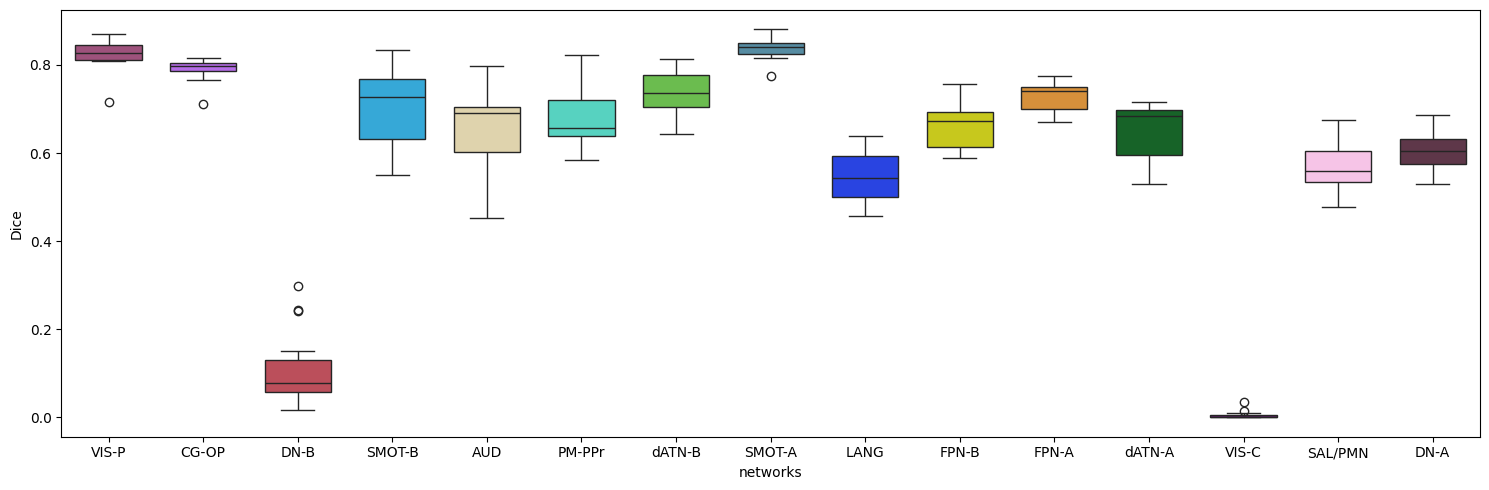

In [4]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/dice_HCP40+RANDYrest-5run_indiv_vs_du15_k-15.tsv', sep='\t')
results = results.loc[(results["strength"]==1) & (results["spatial_w"]==0)]
df_melted = results.melt(id_vars=["subject","strength", "spatial_w"], var_name="networks", value_name="Dice")

import sys
sys.path.append('/PHShome/dz010/Workspace/IndividualParcellation/scripts')

from IndividualParcellation.scripts.indiv_eval_hcp import *
DU15, net_name, colors = gp.get_DU15_parcellation(file_name='DU15NET_Prior', atlas_space='fs32k')
color_list = [tuple(color) for color in colors[1:,:]]

plt.figure(figsize=(15,5))
sb.boxplot(data=df_melted, x="networks", y="Dice", palette=color_list, width=0.7)

plt.tight_layout()
plt.show()

# Evaluation

## 1. choose the optimal hyper-parameters

There are two sets of hyper-parameters to be decided, one is the strengthness of the group prior `group_strength` in the Baysian integration. Higher the strengthness, the resulting individual parcellation is more close to group prior. Another parameter is the spatial smoothness factor `spatial_smoothness` of the m-RBM model which smoothes the functional boundaries of the individual parcellations. The higher the value, the smoother the boundaries. 

The search of this optimal parameters will not rely on a separate *validataion set* as there are only 15 participants in RANDY15 dataset. Instead, we will locate this combination using pure resting state individual data. Specifically, we use 5 runs of rs-fMRI data to infer the individual parcellation, then evaluate their performance on another independent 5 runs rs-fMRI data from the same subjects in terms of DCBC and resting-state global homogeneity. A higher DCBC and homogeneity value indicates the parcellation aligns with the functional boundaries well. After we found the optimal parameters, we will apply it when generating pure task or task and rest fusion individual parcellations, rather than re-search this combination again, making the these hyper-parameters consistent across different data modalities.

The reason doing this is the hyper-parameters are directly related to the quality of the individual data of the studies dataset. The functional MRI data are collected using the same scanner that having the similar spatial/temporal resolution across different modalities (rest or task). If the parameters are optimal in rest data, then it should hold for task or task+rest.

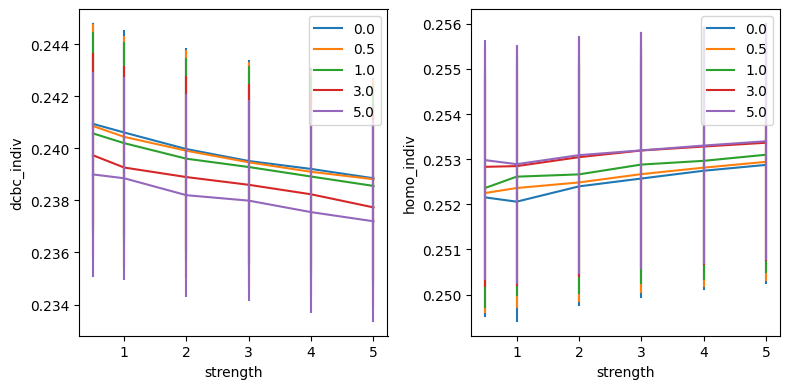

In [6]:
res_L = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40+RANDYrest-5run_indiv_k-15_test_on_RANDYrest_Tseries_hemis-L.tsv', sep='\t')
res_R = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40+RANDYrest-5run_indiv_k-15_test_on_RANDYrest_Tseries_hemis-R.tsv', sep='\t')
results = pd.concat([res_L, res_R], ignore_index=True)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,2,2)
sb.lineplot(data=results, x="strength", y='homo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

The above grid search doesn't give us a clear answer of which combination has the significant advantage. One major reason is the very high data quality of the RANDY15 dataset that provides reliable and robust SNR across different runs, resulting in the individual parcellation roughly the same using different hyper-parameters. However, a clear winning combination will be given if the underlying studies datasets having lower quality, as we observed previously in HCP and MSC dataset.

But in this case, I just select the indiv parcellations by `group_strength=1` and `spatial_smoothness=0` for our main analysis (There are also no spatial regularization in Du's paper when implementing MSHBM).

## Mean Z values (Within-Individual Task Activation Analysis)

For each task contrast, the average z value was calculated for all vertices within each selected network, combining across hemispheres. Mean z values were computed for each task run, and the cross-run mean z values for each network were then plotted in a bar graph, along with the standard error of the mean across participants. This analysis has the advantage of quantifying the magnitude and variance of the response in each a priori-defined network for each participant, without any subjective decisions.

In [5]:
import sys
sys.path.append('/PHShome/dz010/Workspace/IndividualParcellation/scripts')

from IndividualParcellation.scripts.indiv_eval_hcp import *
HCP_DIR = '/data/tge/Tian/HCP_img'

align, net_name, colors = get_kong2019_17_parcellation()
DU15, net_name, colors = gp.get_DU15_parcellation(file_name='DU15NET_Prior', atlas_space='fs32k')

t_data, t_info = load_randy_contrasts(ses_id='all', subj=None, hemis='L', smooth=2)
pd.set_option('display.max_rows', None)
t_info['task_name'] = t_info['domain']
t_info

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


,sn,cond_id,contrast_name,domain,task_name
0,sub-02,1,PASTFUTUREmPRESENT,Episodic_Projection,Episodic_Projection
1,sub-02,2,GLUTESmALL,Motor,Motor
2,sub-02,3,RFOOTmLFOOT,Motor,Motor
3,sub-02,4,RHANDmLHAND,Motor,Motor
4,sub-02,5,TONGUEmALL,Motor,Motor
5,sub-02,6,2BACKm0BACK_ALL,N-Back,N-Back
6,sub-02,7,2BACKm0BACK_FACE,N-Back,N-Back
7,sub-02,8,2BACKm0BACK_LETTER,N-Back,N-Back
8,sub-02,9,2BACKm0BACK_RHYME,N-Back,N-Back
9,sub-02,10,2BACKm0BACK_SCENE,N-Back,N-Back


As an example from a subject. There are total 17 task contrasts of interest in their paper across 7 task domains. In their results, they focused on higher-order domains, including EPROJ, NBACK, ODDBALL, SENTENCEPROCESSING, TOM. However, it is worth noting that not all subjects have the full 17 task contrasts.

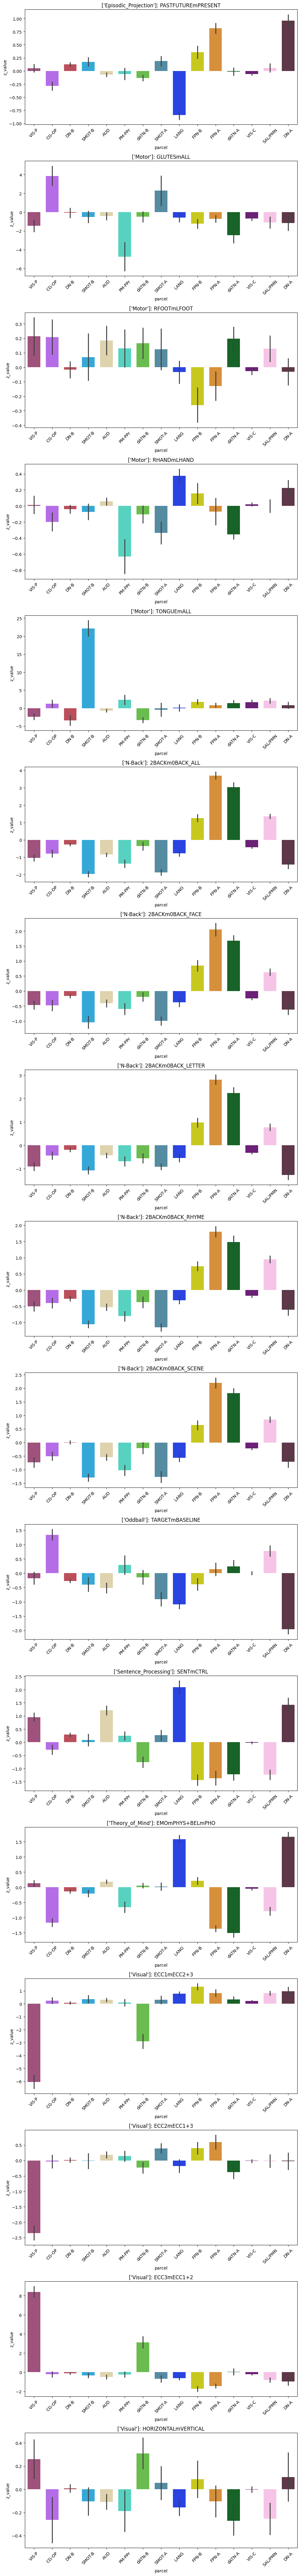

In [11]:
d_type = ['rest-2run', 'task-2run', 'rest+task']
color_list = [tuple(color) for color in colors[1:,:]]

res = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP40+RANDYrest-5run-indiv_K-15_strengh-1_spatial-0.npy')

df_all = pd.DataFrame()
for i in range(17):
    df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
    df_all = pd.concat([df_all, df], ignore_index=True)

con_nam = df_all['contrast_name'].unique()
plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', errorbar='se', palette=color_list, width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

I don't have Jingnan's results table so that I cannot generate network-to-network comparison in this plot. So I have to compare the values in their paper with ours. The general pattern matches, while the main differences are in DN-A, DN-B, and Language networks.

## Using all runs resting-state data

(15, 15, 17) (15, 15, 17)


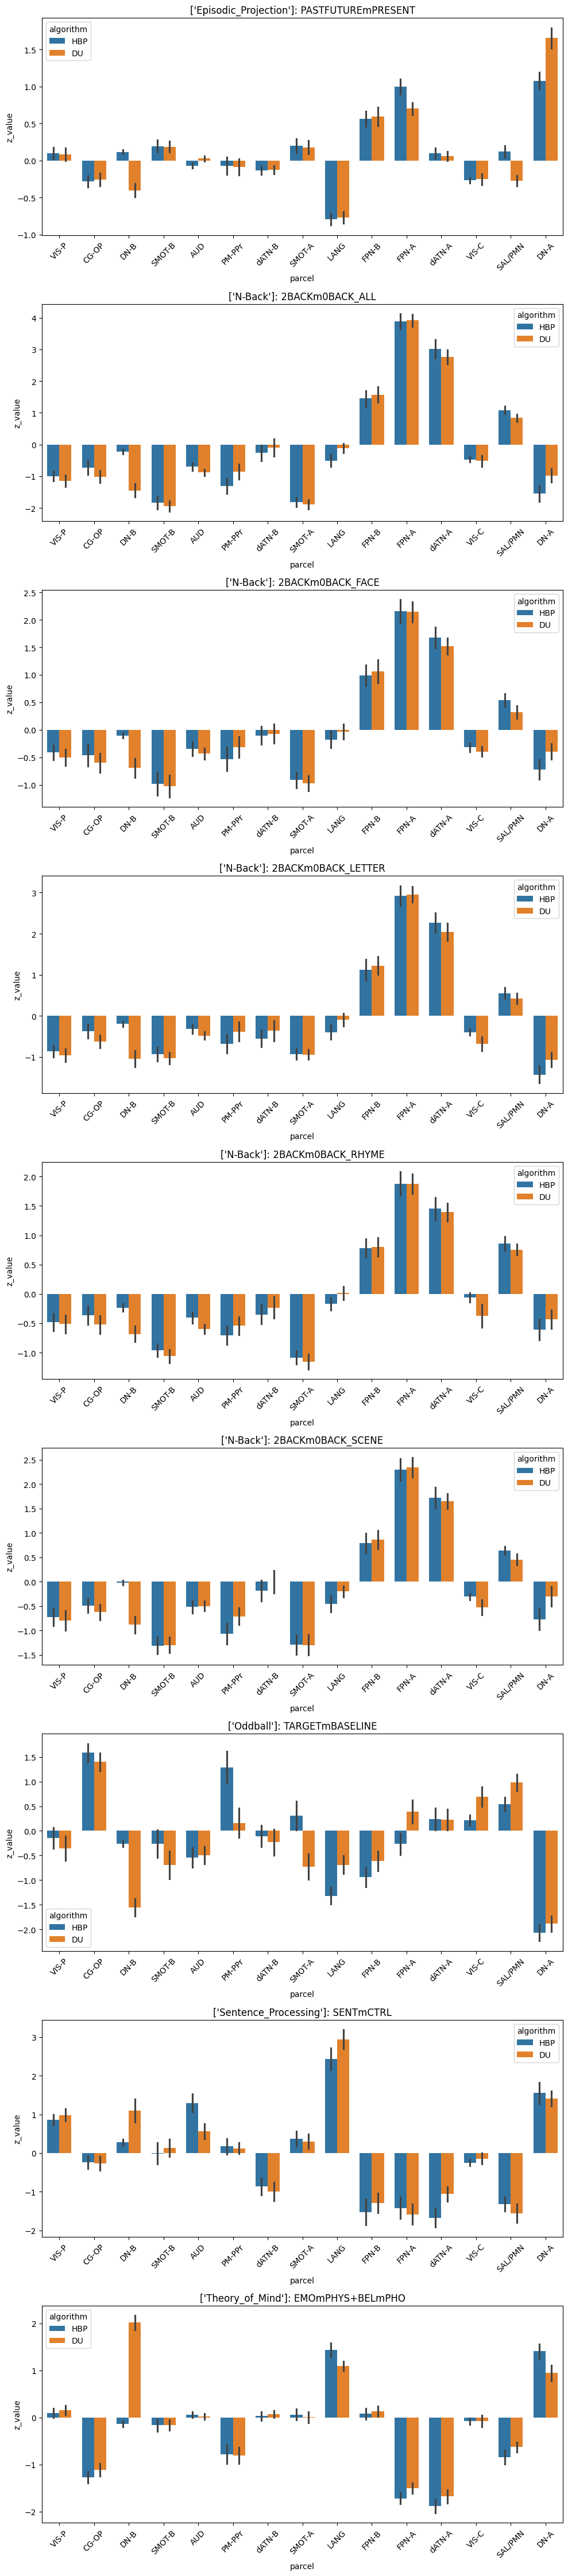

In [12]:
color_list = [tuple(color) for color in colors[1:,:]]

res_hbp = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP40+RANDYrest-allrun-indiv_K-15_strengh-1_spatial-0.npy')

res_du = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_DU-indiv_K-15.npy')

print(res_hbp.shape, res_du.shape)
df_all = pd.DataFrame()
for i in range(17):
    df1 = plot_zvalues(res_hbp, i, t_info, parcel_name=net_name[1:])
    df2 = plot_zvalues(res_du, i, t_info, parcel_name=net_name[1:])
    df1['algorithm']='HBP'
    df2['algorithm']='DU'
    
    df_all = pd.concat([df_all, df1, df2], ignore_index=True)

con_nam = ['PASTFUTUREmPRESENT', '2BACKm0BACK_ALL', '2BACKm0BACK_FACE', '2BACKm0BACK_LETTER', 
           '2BACKm0BACK_RHYME', '2BACKm0BACK_SCENE', 'TARGETmBASELINE', 'SENTmCTRL', 'EMOmPHYS+BELmPHO']
plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', errorbar='se', hue='algorithm', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

# Further comparison

## 1. Same K=15, different HCP 40 training subjects

By using Yeo's data that averaged across their QC 40 subjects. The visual hierachy appears and DN-A and DN-B are now separated.

## 2. Same HCP 40 training subjects, K=15 vs. K=17

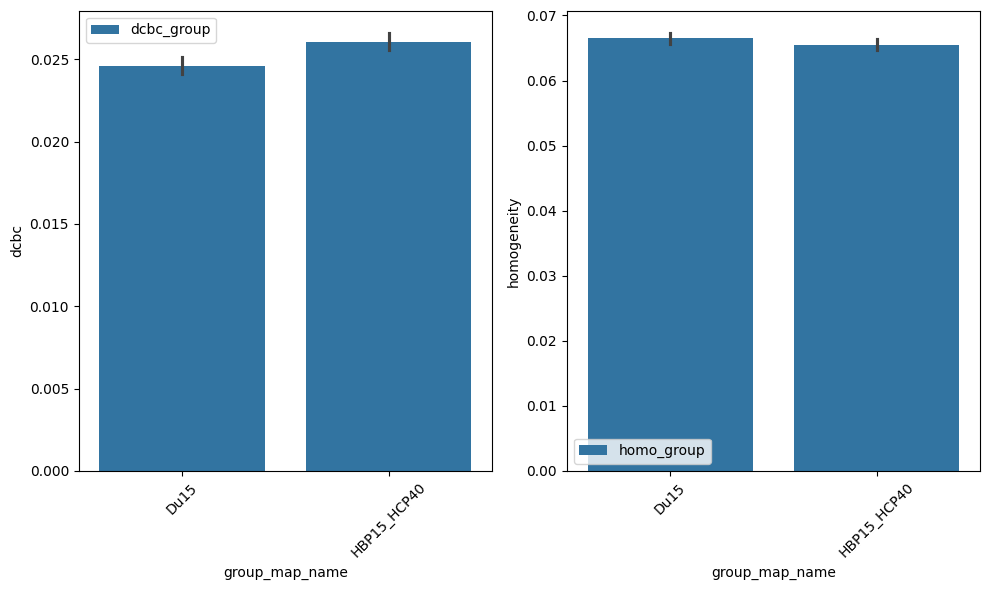

In [6]:
res_dir = '/data/tge/dzhi/Indiv_par/Evaluations'
results = pd.DataFrame()

for i in [0,1,2,3]:
        df = pd.read_csv(res_dir + f'/eval_group_DU_vs_HBP_K-15_on-HCP203test-rsTseries-run{i}_hemis-L.tsv', sep='\t')
        results = pd.concat([results, df], ignore_index=True)

results = results.loc[results["group_map_name"] != 'HBP15_Hc40Md']
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se",
            label='dcbc_group')

plt.ylabel('dcbc')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_group', errorbar="se",
            label='homo_group')

plt.ylabel('homogeneity')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

## Evaluate group prior on Randay 15 dataset rs-Tseries (10 runs / subject)

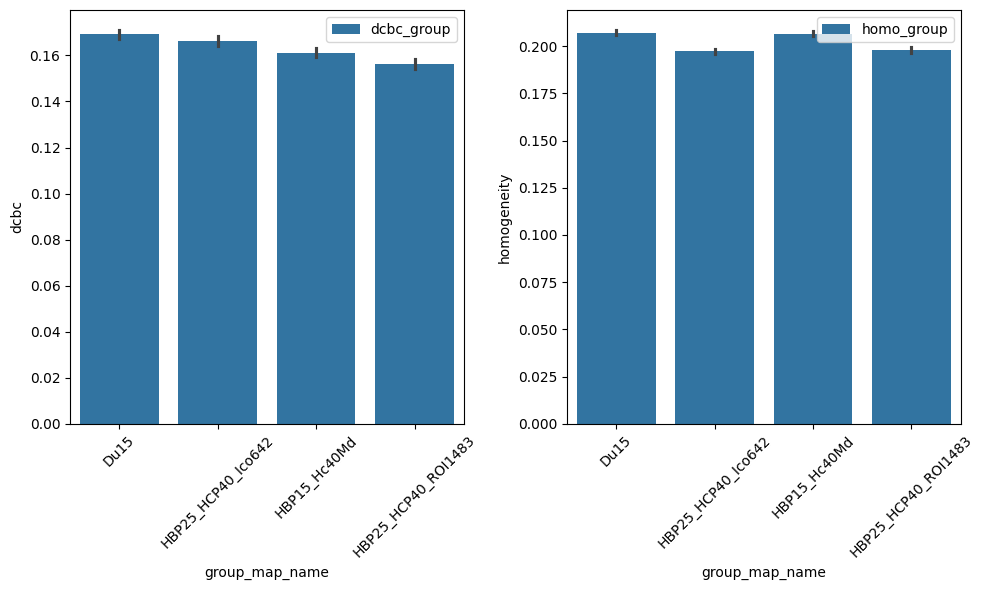

0.16325215377166666 0.202280722325


In [4]:
res_dir = '/data/tge/dzhi/Indiv_par/Evaluations'
df1 = pd.read_csv(res_dir + f'/eval_group_DU_vs_HBP_K-15_on-RANDY15test-rsTseries-10run_hemis-L.tsv', sep='\t')
df2 = pd.read_csv(res_dir + f'/eval_group_DU_vs_HBP_K-15_on-RANDY15test-rsTseries-10run_hemis-R.tsv', sep='\t')

df1_new = pd.read_csv(res_dir + f'/eval_group_DU_vs_HBP_K-15_on-RANDY15test-rsTseries-10run_hemis-L_new_all.tsv', sep='\t')
df2_new = pd.read_csv(res_dir + f'/eval_group_DU_vs_HBP_K-15_on-RANDY15test-rsTseries-10run_hemis-R_new_all.tsv', sep='\t')
df1_new = df1_new.loc[df1_new["group_map_name"] == "HBP15_HCP40_ROI1483_iter23"]
df2_new = df2_new.loc[df2_new["group_map_name"] == "HBP15_HCP40_ROI1483_iter23"]

results = pd.concat([df1, df1_new, df2, df2_new], ignore_index=True)
results = results.replace(['HBP15_HCP40_ROI1483_iter23','HBP15_HCP40'],['HBP25_HCP40_ROI1483', 'HBP25_HCP40_Ico642'])

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se",
            label='dcbc_group')

plt.ylabel('dcbc')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_group', errorbar="se",
            label='homo_group')

plt.ylabel('homogeneity')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

DU_dcbc = results.dcbc_group.mean()
DU_homo = results.homo_group.mean()
print(DU_dcbc, DU_homo)

In [26]:
import HierarchBayesParcel.evaluation as hev
import scripts.group_parcellation as gp
atlas, _ = am.get_atlas('fs32k')

DU15, net_name, colors = gp.get_DU15_parcellation(file_name='DU15NET_Prior', atlas_space='fs32k')
HBP15_roi1483 = atlas.cifti_to_data('/data/tge/dzhi/Indiv_par/Models/Models_03' + 
                                    '/asym_Hc_space-fs32k_K-15_HCP40-Kong_ROI1483Run_sm6fwhm_binarized.dlabel.nii').reshape(-1)
DU15 = pt.tensor(DU15, dtype=pt.get_default_dtype())
HBP15_roi1483 = pt.tensor(HBP15_roi1483, dtype=pt.get_default_dtype())
net_name = net_name[1:]

dice, matching = hev.dice_coefficient(DU15, HBP15_roi1483, label_matching=True, separate=True, return_match=True)
matching = pt.stack(matching)[:,0]-1

df = pd.DataFrame({
    'network': [net_name[i] for i in matching.tolist()],
    'Dice': pt.stack(dice).tolist()})

df

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


,network,Dice
0,SMOT-A,0.920805
1,VIS-P,0.901957
2,CG-OP,0.865311
3,PM-PPr,0.864895
4,VIS-C,0.834128
5,dATN-B,0.832726
6,FPN-A,0.807083
7,FPN-B,0.791837
8,SAL/PMN,0.786093
9,SMOT-B,0.756458


## Comparison using the same group prior

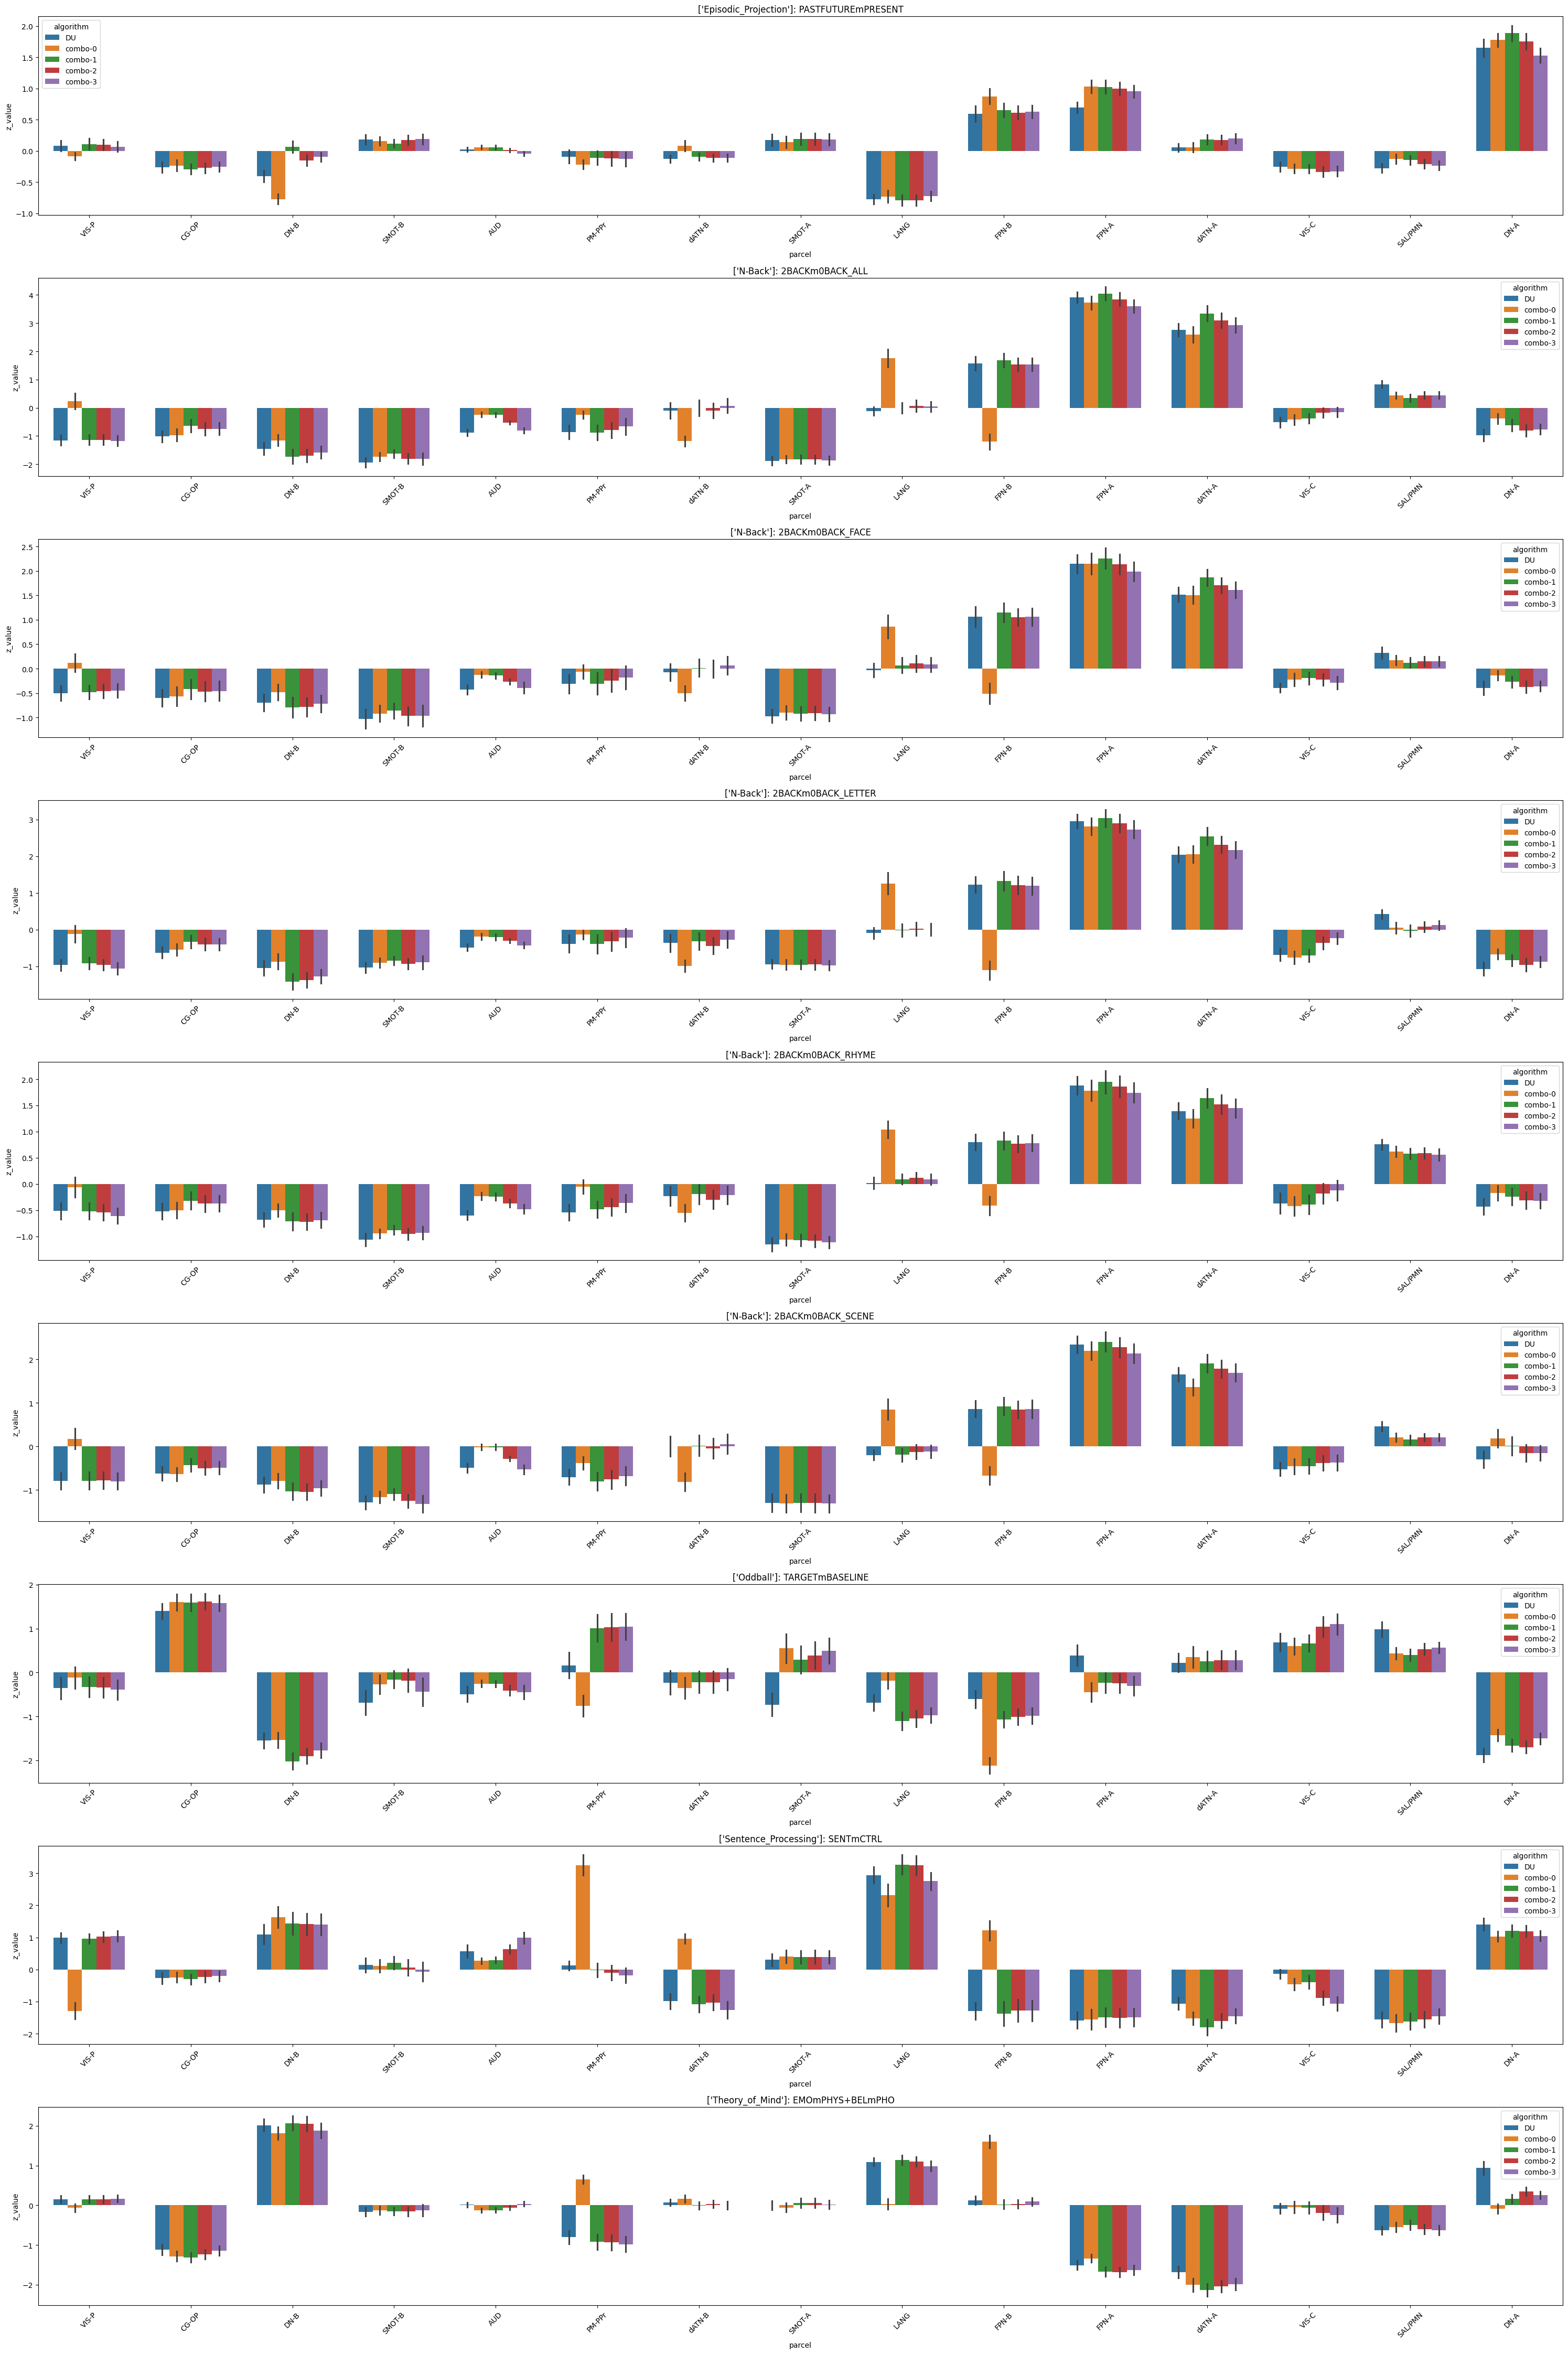

In [11]:
color_list = [tuple(color) for color in colors[1:,:]]

# res_hbp = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
#               '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun-indiv_K-15_strengh-1_spatial-1.npy')

res_du = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_DU-indiv_K-15.npy')
res_new1 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-0.1_spatial-0.npy')
res_new2 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-0.1_spatial-0.5.npy')
res_new3 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-0.1_spatial-1.npy')
res_new4 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-0.1_spatial-2.npy')
res_new5 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-1_spatial-0.npy')
res_new6 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-1_spatial-0.5.npy')
res_new7 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-1_spatial-1.npy')
res_new8 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-1_spatial-2.npy')
res_new9 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-10_spatial-0.npy')
res_new10 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-10_spatial-0.5.npy')
res_new11 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-10_spatial-1.npy')
res_new12 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-10_spatial-2.npy')
res_new13 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-50_spatial-0.npy')
res_new14 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-50_spatial-0.5.npy')
res_new15 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-50_spatial-1.npy')
res_new16 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-allrun_Ico642Run_indiv_K-15_arr-wcRBM_strengh-50_spatial-2.npy')
res_all = [res_new1,
          res_new5,
          res_new9,
          res_new13]

df_all = pd.DataFrame()
for i in range(17):
    df1 = plot_zvalues(res_du, i, t_info, parcel_name=net_name[1:])

    df2_all = pd.DataFrame()
    for j, this_res in enumerate(res_all):
        df2 = plot_zvalues(this_res, i, t_info, parcel_name=net_name[1:])
        df2['algorithm']= f'combo-{j}'
        df2_all = pd.concat([df2_all, df2], ignore_index=True)
        
    df1['algorithm']='DU'
    
    df_all = pd.concat([df_all, df1, df2_all], ignore_index=True)

con_nam = ['PASTFUTUREmPRESENT', '2BACKm0BACK_ALL', '2BACKm0BACK_FACE', '2BACKm0BACK_LETTER', 
           '2BACKm0BACK_RHYME', '2BACKm0BACK_SCENE', 'TARGETmBASELINE', 'SENTmCTRL', 'EMOmPHYS+BELmPHO']
plt.figure(figsize=(30, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', errorbar='se', hue='algorithm', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')

# plt.savefig('/data/tge/dzhi/Indiv_par/figures/zvalue_compare.pdf', format='pdf')
plt.tight_layout()
plt.show()

## How much information preserved by different rsFC calculation?

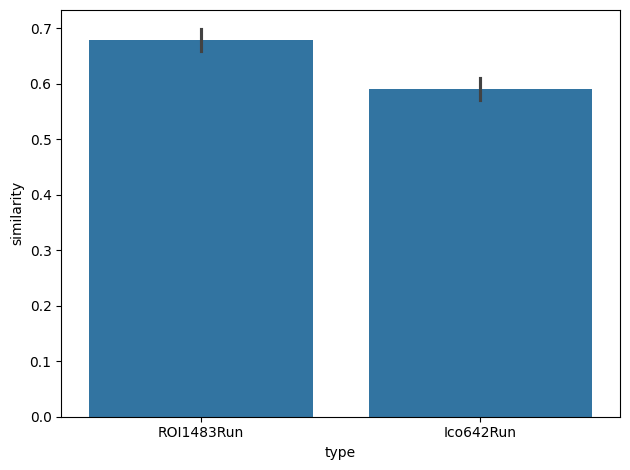

In [6]:
res_dir = '/data/tge/dzhi/Indiv_par/Evaluations'
df1 = pd.read_csv(res_dir + f'/rsfc_similarity_ROI1483.csv', sep='\t')
df2 = pd.read_csv(res_dir + f'/rsfc_similarity_Ico642.tsv', sep='\t')
results = pd.concat([df1, df2], ignore_index=True)

sb.barplot(data=results, x="type", y='similarity', errorbar="se")

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()